# SmartWaste AI — Training YOLOv8m untuk Deteksi Real-Time

Notebook ini melatih model YOLOv8m menggunakan dataset **Garbage Classification 3** (10.464 gambar, 7 kelas) yang diambil langsung dari **Google Drive** folder `SmartWaste_DatasetYoloV8`, lalu di-remap otomatis menjadi **5 kelas Indonesia: plastik, kertas, kaca, logam, organik**.

Dilengkapi fitur **auto-save ke Google Drive** setiap 10 epoch agar hasil training tidak hilang saat sesi Colab berakhir.

---

**Sebelum lanjut:**
1. Set runtime ke GPU: `Runtime > Change runtime type > T4 GPU`
2. Pastikan file `GARBAGE CLASSIFICATION 3.v2-gc1.yolov8.zip` sudah ada di Google Drive kamu di folder `SmartWaste_DatasetYoloV8`
3. Jalankan cell secara berurutan dari atas ke bawah


## Cell 1 — Install dependencies

In [ ]:
# Cell 1 — Install dependencies
!pip install ultralytics -q
print("✅ Ultralytics terinstall!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.7 MB/s eta 0:00:00
✅ Ultralytics terinstall!


## Cell 2 — Cek GPU

In [ ]:
# Cell 2 — Cek GPU
import torch
print("GPU tersedia:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("✅ Device:", torch.cuda.get_device_name(0))
else:
    print("⛔ STOP — ubah Runtime > Change runtime type > GPU sebelum lanjut!")

GPU tersedia: True
✅ Device: Tesla T4


## Cell 3 — Mount Google Drive & Konfigurasi Path

Cell ini akan meminta izin akses ke Google Drive kamu.
Pastikan file zip dataset ada di: `Drive Saya > SmartWaste_DatasetYoloV8`

In [ ]:
# Cell 3 — Mount Google Drive & konfigurasi semua path
from google.colab import drive
import os

drive.mount('/content/drive')

# ============================================================
# KONFIGURASI PATH — sesuaikan jika nama folder berbeda
# ============================================================
DRIVE_BASE       = "/content/drive/MyDrive/SmartWaste_DatasetYoloV8"
DRIVE_SAVE_DIR   = "/content/drive/MyDrive/SmartWaste_DatasetYoloV8/hasil_training"

# Nama file zip dataset di dalam folder Drive
# Sesuaikan jika nama file kamu berbeda
ZIP_FILENAME     = "GARBAGE CLASSIFICATION 3.v2-gc1.yolov8.zip"

# Path lokal di Colab (sementara, hilang saat session habis)
DATASET_PATH     = "/content/dataset_yolo"
REMAPPED_PATH    = "/content/dataset_remapped"
# ============================================================

ZIP_PATH = os.path.join(DRIVE_BASE, ZIP_FILENAME)

# Buat folder hasil_training di Drive jika belum ada
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

# Verifikasi file zip ditemukan
if os.path.exists(ZIP_PATH):
    size_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)
    print(f"✅ File dataset ditemukan: {ZIP_FILENAME}")
    print(f"   Ukuran: {size_mb:.1f} MB")
    print(f"   Path  : {ZIP_PATH}")
else:
    print(f"⛔ File tidak ditemukan: {ZIP_PATH}")
    print(f"   Isi folder Drive kamu:")
    if os.path.exists(DRIVE_BASE):
        for f in os.listdir(DRIVE_BASE):
            print(f"     - {f}")
    else:
        print(f"   Folder '{DRIVE_BASE}' tidak ada. Cek nama folder di Drive kamu.")

print(f"\n📁 Hasil training akan disimpan otomatis ke:")
print(f"   {DRIVE_SAVE_DIR}")

Mounted at /content/drive
✅ File dataset ditemukan: GARBAGE CLASSIFICATION 3.v2-gc1.yolov8.zip
   Ukuran: 201.4 MB
   Path  : /content/drive/MyDrive/SmartWaste_DatasetYoloV8/GARBAGE CLASSIFICATION 3.v2-gc1.yolov8.zip

📁 Hasil training akan disimpan otomatis ke:
   /content/drive/MyDrive/SmartWaste_DatasetYoloV8/hasil_training


## Cell 4 — Ekstrak Dataset dari Google Drive

In [ ]:
# Cell 4 — Copy zip ke lokal Colab dulu, baru ekstrak
# (langsung ekstrak dari Drive path sering error Errno 107 karena koneksi putus)
import zipfile, shutil

LOCAL_ZIP = "/content/dataset.zip"

# Hapus folder lama jika sudah ada (fresh start)
if os.path.exists(DATASET_PATH):
    shutil.rmtree(DATASET_PATH)
    print("🗑️  Folder dataset lama dihapus.")

# Step 1: Copy zip dari Drive ke storage lokal Colab (/content)
# Ini jauh lebih stabil karena I/O tidak bergantung koneksi Drive saat ekstrak
print(f"📋 Step 1: Copy zip dari Drive ke lokal Colab...")
print(f"   Sumber : {ZIP_PATH}")
print(f"   Tujuan : {LOCAL_ZIP}")
print("   (Estimasi waktu: 1–3 menit untuk file 200MB)")

shutil.copy(ZIP_PATH, LOCAL_ZIP)
size_mb = os.path.getsize(LOCAL_ZIP) / (1024 * 1024)
print(f"   ✅ Copy selesai! Ukuran lokal: {size_mb:.1f} MB")

# Step 2: Ekstrak dari file lokal (aman, tidak bergantung Drive)
print(f"\n📦 Step 2: Ekstrak ke {DATASET_PATH}...")
with zipfile.ZipFile(LOCAL_ZIP, 'r') as z:
    z.extractall(DATASET_PATH)

# Hapus zip lokal untuk hemat disk space
os.remove(LOCAL_ZIP)
print("   🗑️  File zip lokal dihapus (hemat disk).")

print("\n✅ Ekstrak selesai! Isi folder dataset:")
for f in sorted(os.listdir(DATASET_PATH)):
    print(f"   {f}")

📋 Step 1: Copy zip dari Drive ke lokal Colab...
   Sumber : /content/drive/MyDrive/SmartWaste_DatasetYoloV8/GARBAGE CLASSIFICATION 3.v2-gc1.yolov8.zip
   Tujuan : /content/dataset.zip
   (Estimasi waktu: 1–3 menit untuk file 200MB)
   ✅ Copy selesai! Ukuran lokal: 201.4 MB

📦 Step 2: Ekstrak ke /content/dataset_yolo...
   🗑️  File zip lokal dihapus (hemat disk).

✅ Ekstrak selesai! Isi folder dataset:
   README.dataset.txt
   README.roboflow.txt
   data.yaml
   test
   train
   valid


## Cell 5 — Cek Struktur Dataset Asli

In [ ]:
# Cell 5 — Cek data.yaml asli
import yaml

yaml_path = f"{DATASET_PATH}/data.yaml"
with open(yaml_path) as f:
    data_yaml = yaml.safe_load(f)

print("📋 Informasi dataset asli:")
print(f"   Jumlah kelas : {data_yaml['nc']}")
print(f"   Nama kelas   : {data_yaml['names']}")
print()

for split in ["train", "valid", "test"]:
    folder = f"{DATASET_PATH}/{split}/images"
    if os.path.exists(folder):
        print(f"   {split:6s}: {len(os.listdir(folder))} gambar")

📋 Informasi dataset asli:
   Jumlah kelas : 6
   Nama kelas   : ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC']

   train : 7324 gambar
   valid : 2098 gambar
   test  : 1042 gambar


## Cell 6 — Remap Kelas ke 5 Kelas Indonesia

Dataset asli punya 7 kelas (`paper`, `plastic`, `glass`, `metal`, `cardboard`, `biodegradable`, `cloth`). Proses remap:
- Merge `cardboard` → `kertas` (digabung dengan `paper`)
- Rename semua ke Bahasa Indonesia
- **Buang** kelas `cloth` karena tidak relevan untuk SmartWaste

In [ ]:
# Cell 6 — Remap kelas otomatis ke 5 kelas Indonesia
import os, yaml, shutil

yaml_path = f"{DATASET_PATH}/data.yaml"
with open(yaml_path) as f:
    data_yaml = yaml.safe_load(f)

original_names = data_yaml["names"]
print("Kelas asli:", original_names)

# Mapping kelas asli → kelas Indonesia (None = buang)
CLASS_REMAP = {
    "paper":         "kertas",
    "cardboard":     "kertas",
    "plastic":       "plastik",
    "glass":         "kaca",
    "metal":         "logam",
    "biodegradable": "organik",
    "cloth":         None,
    "PAPER":         "kertas",
    "CARDBOARD":     "kertas",
    "PLASTIC":       "plastik",
    "GLASS":         "kaca",
    "METAL":         "logam",
    "BIODEGRADABLE": "organik",
    "CLOTH":         None,
}

FINAL_CLASSES = ["kaca", "kertas", "logam", "organik", "plastik"]
final_idx = {c: i for i, c in enumerate(FINAL_CLASSES)}

old_to_new = {}
for old_idx, old_name in enumerate(original_names):
    new_name = CLASS_REMAP.get(old_name, CLASS_REMAP.get(old_name.lower()))
    old_to_new[old_idx] = final_idx[new_name] if new_name is not None else None

print("\nMapping index:")
for old_idx, new_idx in old_to_new.items():
    old_name = original_names[old_idx]
    new_name = FINAL_CLASSES[new_idx] if new_idx is not None else "DIBUANG"
    status = "✅" if new_idx is not None else "❌"
    print(f"  {status} [{old_idx}] {old_name:15s} → [{new_idx}] {new_name}")

# Proses ulang semua file label .txt
if os.path.exists(REMAPPED_PATH):
    shutil.rmtree(REMAPPED_PATH)

total_kept = 0
total_dropped = 0

for split in ["train", "valid", "test"]:
    img_src = f"{DATASET_PATH}/{split}/images"
    lbl_src = f"{DATASET_PATH}/{split}/labels"
    img_dst = f"{REMAPPED_PATH}/{split}/images"
    lbl_dst = f"{REMAPPED_PATH}/{split}/labels"

    if not os.path.exists(img_src):
        continue

    os.makedirs(img_dst, exist_ok=True)
    os.makedirs(lbl_dst, exist_ok=True)

    for img_file in os.listdir(img_src):
        base = os.path.splitext(img_file)[0]
        lbl_file = base + ".txt"
        lbl_path = os.path.join(lbl_src, lbl_file)

        if not os.path.exists(lbl_path):
            continue

        new_lines = []
        with open(lbl_path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                old_cls = int(parts[0])
                new_cls = old_to_new.get(old_cls)
                if new_cls is not None:
                    new_lines.append(f"{new_cls} {' '.join(parts[1:])}")
                    total_kept += 1
                else:
                    total_dropped += 1

        shutil.copy(os.path.join(img_src, img_file), os.path.join(img_dst, img_file))
        with open(os.path.join(lbl_dst, lbl_file), 'w') as f:
            f.write('\n'.join(new_lines))

print(f"\n✅ Selesai remap!")
print(f"   Anotasi dipakai : {total_kept}")
print(f"   Anotasi dibuang : {total_dropped} (kelas cloth)")

# Tulis data.yaml baru
new_yaml = {
    "train": f"{REMAPPED_PATH}/train/images",
    "val":   f"{REMAPPED_PATH}/valid/images",
    "test":  f"{REMAPPED_PATH}/test/images",
    "nc":    len(FINAL_CLASSES),
    "names": FINAL_CLASSES,
}
new_yaml_path = f"{REMAPPED_PATH}/data.yaml"
with open(new_yaml_path, 'w') as f:
    yaml.dump(new_yaml, f, default_flow_style=False, allow_unicode=True)

print(f"\n📄 data.yaml baru:")
print(f"   nc    : {new_yaml['nc']}")
print(f"   names : {new_yaml['names']}")

Kelas asli: ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC']

Mapping index:
  ✅ [0] BIODEGRADABLE   → [3] organik
  ✅ [1] CARDBOARD       → [1] kertas
  ✅ [2] GLASS           → [0] kaca
  ✅ [3] METAL           → [2] logam
  ✅ [4] PAPER           → [1] kertas
  ✅ [5] PLASTIC         → [4] plastik

✅ Selesai remap!
   Anotasi dipakai : 74090
   Anotasi dibuang : 0 (kelas cloth)

📄 data.yaml baru:
   nc    : 5
   names : ['kaca', 'kertas', 'logam', 'organik', 'plastik']


## Cell 7 — Verifikasi Dataset Hasil Remap

In [ ]:
# Cell 7 — Verifikasi hasil remap
from collections import Counter

print("📊 Jumlah gambar per split:")
for split in ["train", "valid", "test"]:
    folder = f"{REMAPPED_PATH}/{split}/images"
    if os.path.exists(folder):
        print(f"   {split:6s}: {len(os.listdir(folder))} gambar")

print("\n📊 Distribusi kelas di train:")
counter = Counter()
lbl_folder = f"{REMAPPED_PATH}/train/labels"
for lbl_file in os.listdir(lbl_folder):
    with open(os.path.join(lbl_folder, lbl_file)) as f:
        for line in f:
            if line.strip():
                cls = int(line.split()[0])
                counter[FINAL_CLASSES[cls]] += 1

total_obj = sum(counter.values())
for cls, count in sorted(counter.items()):
    bar = '█' * (count * 30 // max(counter.values()))
    print(f"   {cls:8s}: {count:5d} objek  {bar}")
print(f"\n   Total : {total_obj} objek")

📊 Jumlah gambar per split:
   train : 7324 gambar
   valid : 2098 gambar
   test  : 1042 gambar

📊 Distribusi kelas di train:
   kaca    :  5429 objek  █████
   kertas  :  6367 objek  ██████
   logam   :  3948 objek  ███
   organik : 31721 objek  ██████████████████████████████
   plastik :  4146 objek  ███

   Total : 51611 objek


## Cell 8 — Setup Auto-Save ke Google Drive

Cell ini mendefinisikan callback yang akan **otomatis menyimpan checkpoint ke Google Drive setiap 10 epoch** dan saat training selesai. Jalankan cell ini sebelum memulai training.

In [ ]:
# Cell 8 — Definisi callback auto-save ke Google Drive
import shutil, time
from datetime import datetime
from ultralytics import YOLO
from ultralytics.utils import callbacks

# Interval auto-save (setiap berapa epoch)
AUTOSAVE_EVERY_N_EPOCH = 10

def on_train_epoch_end(trainer):
    """Callback: simpan checkpoint ke Drive setiap N epoch."""
    epoch = trainer.epoch + 1  # epoch mulai dari 0
    if epoch % AUTOSAVE_EVERY_N_EPOCH == 0:
        timestamp = datetime.now().strftime("%H%M")
        dest_name = f"checkpoint_epoch{epoch:03d}_{timestamp}.pt"
        dest_path = os.path.join(DRIVE_SAVE_DIR, dest_name)

        # Cari last.pt dari folder training aktif
        last_pt = os.path.join(trainer.save_dir, "weights", "last.pt")
        if os.path.exists(last_pt):
            shutil.copy(last_pt, dest_path)
            print(f"\n💾 [Epoch {epoch}] Auto-save → {dest_name}")
        else:
            print(f"\n⚠️  [Epoch {epoch}] last.pt belum ada, lewati auto-save.")

def on_train_end(trainer):
    """Callback: simpan best.pt dan grafik hasil ke Drive saat training selesai."""
    print("\n🏁 Training selesai! Menyimpan hasil ke Google Drive...")

    save_dir = trainer.save_dir
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")

    # Simpan best.pt
    best_pt = os.path.join(save_dir, "weights", "best.pt")
    if os.path.exists(best_pt):
        dest = os.path.join(DRIVE_SAVE_DIR, f"best_{timestamp}.pt")
        shutil.copy(best_pt, dest)
        print(f"   ✅ best.pt  → {dest}")

    # Simpan last.pt
    last_pt = os.path.join(save_dir, "weights", "last.pt")
    if os.path.exists(last_pt):
        dest = os.path.join(DRIVE_SAVE_DIR, f"last_{timestamp}.pt")
        shutil.copy(last_pt, dest)
        print(f"   ✅ last.pt  → {dest}")

    # Simpan results.csv
    results_csv = os.path.join(save_dir, "results.csv")
    if os.path.exists(results_csv):
        dest = os.path.join(DRIVE_SAVE_DIR, f"results_{timestamp}.csv")
        shutil.copy(results_csv, dest)
        print(f"   ✅ results.csv → {dest}")

    # Simpan confusion matrix jika ada
    for fname in ["confusion_matrix.png", "confusion_matrix_normalized.png", "results.png"]:
        fpath = os.path.join(save_dir, fname)
        if os.path.exists(fpath):
            dest = os.path.join(DRIVE_SAVE_DIR, f"{fname.replace('.', f'_{timestamp}.')}")
            shutil.copy(fpath, dest)
            print(f"   ✅ {fname} → disimpan")

    print(f"\n📁 Semua file tersimpan di Drive: SmartWaste_DatasetYoloV8/hasil_training/")

print("✅ Callback auto-save berhasil didefinisikan.")
print(f"   Auto-save interval : setiap {AUTOSAVE_EVERY_N_EPOCH} epoch")
print(f"   Folder tujuan Drive: {DRIVE_SAVE_DIR}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Callback auto-save berhasil didefinisikan.
   Auto-save interval : setiap 10 epoch
   Folder tujuan Drive: /content/drive/MyDrive/SmartWaste_DatasetYoloV8/hasil_training


## Cell 9 — Training YOLOv8m

Training dimulai. Estimasi waktu dengan GPU T4: **~60–80 menit** untuk 100 epoch.
Auto-save akan berjalan otomatis setiap 10 epoch.


In [ ]:
# Cell 9 — Training YOLOv8m dengan auto-save callback
import os
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

# Daftarkan callback auto-save
model.add_callback("on_train_epoch_end", on_train_epoch_end)
model.add_callback("on_train_end", on_train_end)

print("🚀 Memulai training...")
print(f"   Dataset : {REMAPPED_PATH}/data.yaml")
print(f"   Epochs  : 100")
print(f"   Batch   : 16")
print(f"   Imgsz   : 640")
print(f"   Auto-save setiap {AUTOSAVE_EVERY_N_EPOCH} epoch ke Drive\n")

results = model.train(
    data=os.path.abspath(f"{REMAPPED_PATH}/data.yaml"),
    epochs=100,
    imgsz=640,
    batch=16,
    patience=15,
    name="smartwaste_yolov8m",
    workers=2,
    save=True,          # simpan last.pt dan best.pt di lokal
    save_period=10,     # simpan checkpoint lokal setiap 10 epoch
    exist_ok=True,      # lanjutkan jika folder runs sudah ada
)


🚀 Memulai training...
   Dataset : /content/dataset_remapped/data.yaml
   Epochs  : 100
   Batch   : 16
   Imgsz   : 640
   Auto-save setiap 10 epoch ke Drive

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_remapped/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mode

In [ ]:
# Cell Cek Mount — Jalankan ini DULU sebelum cell verifikasi
import os

# 1. Cek apakah Drive sudah ter-mount di sesi runtime ini
if os.path.exists("/content/drive/MyDrive"):
    print("✅ Google Drive SUDAH ter-mount di sesi ini.")
else:
    print("❌ Google Drive BELUM ter-mount di sesi ini.")
    print("   Mounting sekarang...")
    from google.colab import drive
    drive.mount('/content/drive')

# 2. Cek folder spesifik kamu
target = "/content/drive/MyDrive/SmartWaste_DatasetYoloV8/hasil_training"
print("\n📂 Cek folder target:", target)
print("Drive root ada isinya?", os.path.exists("/content/drive/MyDrive"))
print("Folder SmartWaste ada?", os.path.exists("/content/drive/MyDrive/SmartWaste_DatasetYoloV8"))
print("Folder hasil_training ada?", os.path.exists(target))

if os.path.exists(target):
    print("\n✅ File yang ada:")
    for f in sorted(os.listdir(target)):
        print("  -", f)

❌ Google Drive BELUM ter-mount di sesi ini.
   Mounting sekarang...
Mounted at /content/drive

📂 Cek folder target: /content/drive/MyDrive/SmartWaste_DatasetYoloV8/hasil_training
Drive root ada isinya? True
Folder SmartWaste ada? True
Folder hasil_training ada? True

✅ File yang ada:
  - checkpoint_epoch010_1657.pt
  - checkpoint_epoch020_1748.pt
  - checkpoint_epoch030_1839.pt
  - checkpoint_epoch040_1930.pt
  - checkpoint_epoch050_2022.pt
  - checkpoint_epoch060_2113.pt


## Cell 10 — Evaluasi Model

In [ ]:
# Cell 10 — Evaluasi model terbaik
metrics = model.val()

print("📊 Hasil Evaluasi:")
print(f"   mAP50-95 (semua kelas): {round(metrics.box.map, 4)}")
print(f"   mAP50    (semua kelas): {round(metrics.box.map50, 4)}")

print("\n   mAP50 per kelas:")
for i, class_name in enumerate(FINAL_CLASSES):
    score = metrics.box.maps[i]
    bar = '█' * int(score * 20)
    print(f"   {class_name:8s}: {score:.3f}  {bar}")

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 759.1±430.1 MB/s, size: 19.4 KB)
val: Scanning /content/dataset_remapped/valid/labels.cache... 2098 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2098/2098 586.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 132/132 5.6it/s 23.6s
                   all       2098      18916      0.703      0.531      0.609      0.415
                  kaca        805       2380      0.864      0.686      0.798      0.591
                kertas        449       1325      0.737      0.491      0.592      0.449
                 logam        398       1360      0.733      0.585      0.669      0.451
               organik        676      13637      0.843      0.439      0.615      0.344
               plastik         91 

## Cell 11 — Plot Grafik Training & Simpan ke Drive

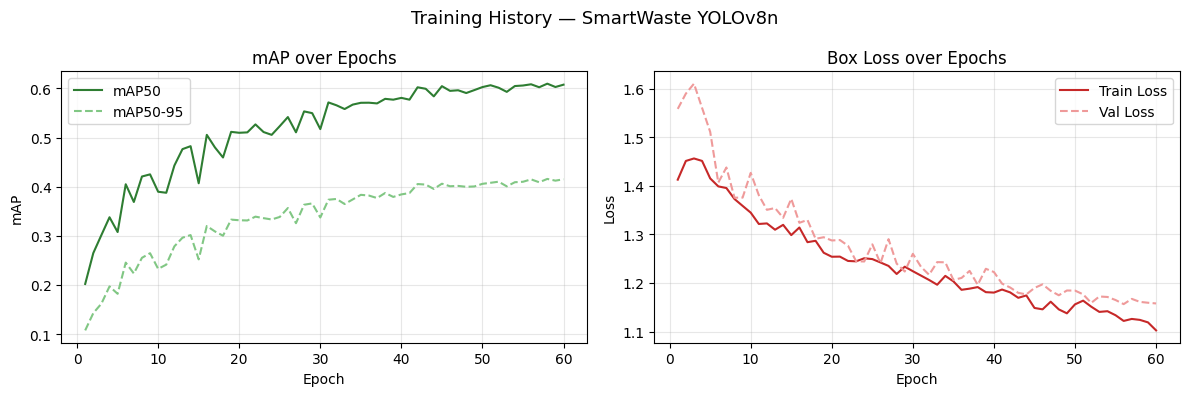

✅ Grafik disimpan ke Drive: training_history_20260618_1345.png


In [ ]:
# Cell 11 — Plot grafik training dan simpan ke Drive
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

results_csv = "runs/detect/smartwaste_yolov8m/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df["epoch"], df["metrics/mAP50(B)"], color="#2e7d32", label="mAP50")
axes[0].plot(df["epoch"], df["metrics/mAP50-95(B)"], color="#81c784", linestyle="--", label="mAP50-95")
axes[0].set_title("mAP over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("mAP")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["epoch"], df["train/box_loss"], color="#c62828", label="Train Loss")
axes[1].plot(df["epoch"], df["val/box_loss"], color="#ef9a9a", linestyle="--", label="Val Loss")
axes[1].set_title("Box Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training History — SmartWaste YOLOv8m", fontsize=13)
plt.tight_layout()

# Simpan ke lokal Colab
local_graph = "yolo_training_history.png"
plt.savefig(local_graph, dpi=150, bbox_inches="tight")
plt.show()

# Simpan grafik ke Google Drive
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
drive_graph = os.path.join(DRIVE_SAVE_DIR, f"training_history_{timestamp}.png")
shutil.copy(local_graph, drive_graph)
print(f"✅ Grafik disimpan ke Drive: training_history_{timestamp}.png")


## Cell 11b — Tampilkan Confusion Matrix

Cell ini menampilkan **confusion matrix** hasil training secara langsung di notebook.
- **Raw count**: jumlah prediksi aktual per kelas
- **Normalized**: proporsi prediksi per kelas (lebih mudah dibaca)

Confusion matrix membantu mengidentifikasi kelas mana yang sering salah diprediksi.

In [ ]:
# Cell 11b — Tampilkan Confusion Matrix
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display

RUNS_DIR = "runs/detect/smartwaste_yolov8m"

# Path ke confusion matrix
cm_path = os.path.join(RUNS_DIR, "confusion_matrix.png")
cm_norm_path = os.path.join(RUNS_DIR, "confusion_matrix_normalized.png")

def show_confusion_matrix(path, title):
    if os.path.exists(path):
        img = mpimg.imread(path)
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title, fontsize=14, pad=12)
        plt.tight_layout()
        plt.show()
        print(f"✅ Ditampilkan: {path}")
    else:
        print(f"⚠️  File tidak ditemukan: {path}")
        print("   Pastikan training sudah selesai dan file ada di folder runs.")

print("📊 Confusion Matrix — SmartWaste YOLOv8m\n")
print("1️⃣  Confusion Matrix (Raw Count):")
show_confusion_matrix(cm_path, "Confusion Matrix — SmartWaste YOLOv8m (Raw Count)")

print("\n2️⃣  Confusion Matrix (Normalized):")
show_confusion_matrix(cm_norm_path, "Confusion Matrix Normalized — SmartWaste YOLOv8m")

# Simpan confusion matrix ke Google Drive
print("\n💾 Menyimpan confusion matrix ke Google Drive...")
from datetime import datetime
import shutil

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
for fname, src_path in [("confusion_matrix.png", cm_path), ("confusion_matrix_normalized.png", cm_norm_path)]:
    if os.path.exists(src_path):
        dst = os.path.join(DRIVE_SAVE_DIR, f"{fname.replace('.png', '')}_{timestamp}.png")
        shutil.copy(src_path, dst)
        print(f"   ✅ Tersimpan → {dst}")
    else:
        print(f"   ⚠️  {fname} tidak ditemukan, skip.")


## Cell 12 — Simpan Manual ke Drive (Opsional)

Jalankan cell ini kapan saja jika ingin menyimpan model secara manual, misalnya di tengah training atau setelah training selesai.

In [ ]:
# Cell 12 — Simpan manual model ke Google Drive (bisa dijalankan kapan saja)
import shutil, os
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
RUNS_DIR = "runs/detect/smartwaste_yolov8m/weights"

files_to_save = [
    (f"{RUNS_DIR}/best.pt",  f"best_manual_{timestamp}.pt"),
    (f"{RUNS_DIR}/last.pt",  f"last_manual_{timestamp}.pt"),
]

print("💾 Simpan manual ke Google Drive:")
for src, dst_name in files_to_save:
    if os.path.exists(src):
        dst = os.path.join(DRIVE_SAVE_DIR, dst_name)
        shutil.copy(src, dst)
        size_mb = os.path.getsize(src) / (1024 * 1024)
        print(f"   ✅ {dst_name} ({size_mb:.1f} MB)")
    else:
        print(f"   ⚠️  {src} belum ada (training belum sampai sini?)")

print(f"\n📁 Tersimpan di: SmartWaste_DatasetYoloV8/hasil_training/")


💾 Simpan manual ke Google Drive:
   ✅ best_manual_20260618_134547.pt (6.0 MB)
   ✅ last_manual_20260618_134547.pt (6.0 MB)

📁 Tersimpan di: SmartWaste_DatasetYoloV8/hasil_training/


## Cell 13 — Download Model ke Komputer Lokal (Opsional)

In [ ]:
# Cell 13 — Download best.pt dan grafik ke komputer lokal
from google.colab import files

best_model_path = "runs/detect/smartwaste_yolov8m/weights/best.pt"
files.download(best_model_path)
files.download("yolo_training_history.png")

print("✅ Download selesai!")
print("📌 Taruh best.pt di folder project Flask: model/yolo/smartwaste_yolo.pt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download selesai!
📌 Taruh best.pt di folder project Flask: model/yolo/smartwaste_yolo.pt


---

## Catatan Penting

| File | Lokasi |
|------|--------|
| Dataset zip | `Drive/SmartWaste_DatasetYoloV8/` |
| Hasil training (otomatis) | `Drive/SmartWaste_DatasetYoloV8/hasil_training/` |
| Model untuk Flask | taruh `best.pt` di `model/yolo/smartwaste_yolo.pt` |

**Tips:**
- Confidence threshold untuk webcam real-time: gunakan **0.4–0.5** agar tidak banyak false positive.
- Kalau mAP kelas `organik` rendah (<0.5), pertimbangkan menambah data dari dataset biological/food waste lain.
- Untuk melanjutkan training dari checkpoint yang tersimpan di Drive, gunakan:
  ```python
  model = YOLO("/content/drive/MyDrive/SmartWaste_DatasetYoloV8/hasil_training/last_YYYYMMDD_HHMM.pt")
  model.train(resume=True)
  ```